Authors: [Maxime Devanne](https://maxime-devanne.com), [Germain Forestier](https://germain-forestier.info/), [Hassan Ismail Fawaz](https://hfawaz.github.io) and [Jonathan Weber](http://jonathan-weber.eu/)

#**Recurrent Neural Networks**

# Import Modules

In [2]:
from pandas import DataFrame
from pandas import Series
from pandas import concat
from pandas import read_csv
import pandas as pd
from datetime import datetime
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras
from math import sqrt
from matplotlib import pyplot as plt
import numpy as np

#Prediction problem

We will first consider a prediction problem as seen in lecture. The goal is to predict how the number of passengers are evolving from the dataset "international-airline-passengers.csv"

## Data preparation

### Load dataset


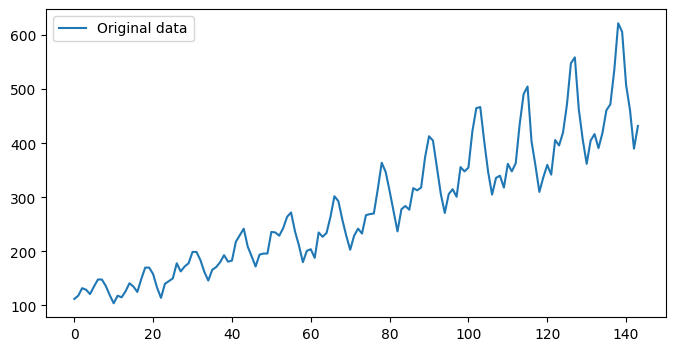

In [3]:
# Load the dataset
passenger_data_url = "https://raw.githubusercontent.com/quratulaincodes/SSR/main/international-airline-passengers.csv"
passenger_dataframe = pd.read_csv(passenger_data_url, usecols=[1], engine='python')

# Plot the original dataset
plt.figure(figsize=(8,4))
plt.plot(passenger_dataframe, label='Original data')
plt.legend()
plt.show()

### Display some of the data

In [4]:
print(passenger_dataframe.head())

   Passengers
0         112
1         118
2         132
3         129
4         121


### Normalize data

In [5]:
# Convert to Numpy Array and Normalize
passenger_array = passenger_dataframe.values.astype('float32')
scaler_toolbox = MinMaxScaler(feature_range=(0, 1))
normalized_passenger_data = scaler_toolbox.fit_transform(passenger_array)

### Divide into train and test

In [6]:
# Divide into Training and Test Segments
partition_size = int(len(normalized_passenger_data) * 0.67)
remainder_size = len(normalized_passenger_data) - partition_size
train_partition, test_partition = normalized_passenger_data[0:partition_size,:], normalized_passenger_data[partition_size:len(normalized_passenger_data),:]

### Divide in X and Y
X corresponds to input at time t and Y corresponds to the target (value at time t+1).
A LSTM layer needs as input a matrix of dimension [nb_samples, time_index, features]:
- nb_samples : number of observations
- time_index : time steps for a given observation (1 in our case (history_length)
- features : 1 in our case : number of passengers

In [7]:
def organize_data(sequence_data, history_length=1):
    input_data, target_data = [], []
    for idx in range(len(sequence_data)-history_length-1):
        fragment = sequence_data[idx:(idx+history_length), 0]
        input_data.append(fragment)
        target_data.append(sequence_data[idx + history_length, 0])
    return np.array(input_data), np.array(target_data)

history_length = 1
x_train, y_train = organize_data(train_partition, history_length)
x_test, y_test = organize_data(test_partition, history_length)

x_train = np.reshape(x_train, (x_train.shape[0], 1, x_train.shape[1]))
x_test = np.reshape(x_test, (x_test.shape[0], 1, x_test.shape[1]))

## Predict with LSTM

### Build a LSTM
At each time step t, the goal is to predict the value at t+1. We then use a batch size of 1.


In [8]:
batch_size = 1
nb_neurons = 4

# input layer
input_layer = keras.layers.Input(batch_shape=[batch_size,x_train.shape[1],x_train.shape[2]])

# first hidden layer of an LSTM containing nb_neurons
hidden_layer_1 = keras.layers.LSTM(units=nb_neurons)(input_layer)

# last linear prediction layer that predicts a single real value
output_layer = keras.layers.Dense(units=1)(hidden_layer_1)

# create model
model = keras.models.Model(inputs=input_layer, outputs=output_layer)

model.summary()

# cost function for regression
cost_function = keras.losses.MeanSquaredError

# optimization method
optimizer_algo = keras.optimizers.Adam(learning_rate=0.001)

# compilmodel
model.compile(loss=cost_function, optimizer=optimizer_algo)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (1, 1, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (1, 4)                 │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 1)                 │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101 (404.00 B)

 Trainable params: 101 (404.00 B)

 Non-trainable params: 0 (0.00 B)

### Train network

Train the model on 100 epochs

In [9]:
model.fit(x_train, y_train, epochs=100, batch_size=batch_size, verbose=1)

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 571us/step - loss: 0.0400  
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 510us/step - loss: 0.0176
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 520us/step - loss: 0.0138
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 762us/step - loss: 0.0126
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 598us/step - loss: 0.0114
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 555us/step - loss: 0.0104
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 582us/step - loss: 0.0094
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 550us/step - loss: 0.0084  
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 581us/step - loss: 0.0075
Epoch 10/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 483us/step - loss: 0.0066  
Epoch 11/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 477us/step - loss: 0.0057
Epoch 12/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 476us/step - loss: 0.0050
Epoch 13/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 478us/step - loss: 0.0043  
Epoch 14/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 470us/step - loss: 0.0038
Epoch 15/100
94/94 ━━━━━━━━━━━━━━━━

### Predict the training set

In [10]:
train_predict = model.predict(x_train)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


### Predict on the test set

In [11]:
test_predict = model.predict(x_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


### Inverse transformations to retrieve original scale

In [12]:
x_train_predict = scaler_toolbox.inverse_transform(train_predict)
y_train_transformed = scaler_toolbox.inverse_transform([y_train])
x_test_predict = scaler_toolbox.inverse_transform(test_predict)
y_test_transformed = scaler_toolbox.inverse_transform([y_test])

### Measure RMSE (Root Mean Squared Error)

In [13]:
train_evaluation = np.sqrt(mean_squared_error(y_train_transformed[0], x_train_predict[:,0]))
print('Training Evaluation: %.2f RMSE' % (train_evaluation))
test_evaluation = np.sqrt(mean_squared_error(y_test_transformed[0], x_test_predict[:,0]))
print('Testing Evaluation: %.2f RMSE' % (test_evaluation))

Training Evaluation: 23.12 RMSE
Testing Evaluation: 48.89 RMSE


### Plot prediction

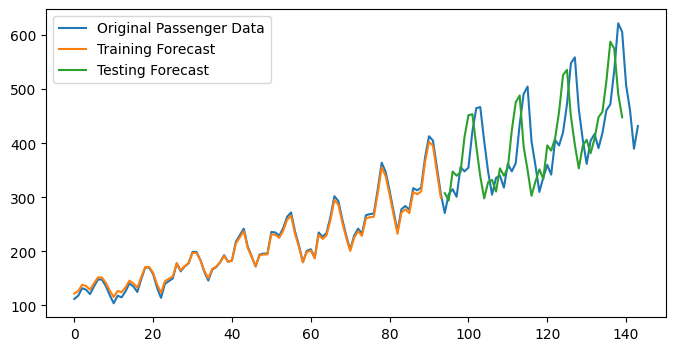

In [14]:
# Visualizing Original Data and Forecasts
plt.figure(figsize=(8,4))
plt.plot(scaler_toolbox.inverse_transform(normalized_passenger_data), label='Original Passenger Data')
plt.plot([item for item in x_train_predict], label='Training Forecast')
plt.plot([item+len(x_train_predict) for item in range(len(x_test_predict))], x_test_predict, label='Testing Forecast')
plt.legend()
plt.show()

## **Exercices**

### Apply the [RNNs](https://keras.io/layers/recurrent/#simplernn) (two layers with 4 neurons each) and compare their performance with the LSTMs

Warning ! To put several recurring layers, you must indicate return_sequences=True in lower layers. This allows to return outputs for each time steps and thus to still have a sequence that will be further used as input of the next layer. By default, the parameter return_sequence=False only return an output for the last time step

In [ ]:
# Your code here

 ### Correction :

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (1, 1, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (1, 1, 4)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (1, 4)                 │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 1)                 │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0361
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0133
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0090
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0056
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0038
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0027
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0023
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0021
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0019
Epoch 10/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0021
Epoch 11/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0020
Epoch 12/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0020
Epoch 13/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0020
Epoch 14/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0020
Epoch 15/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0021
Epoc

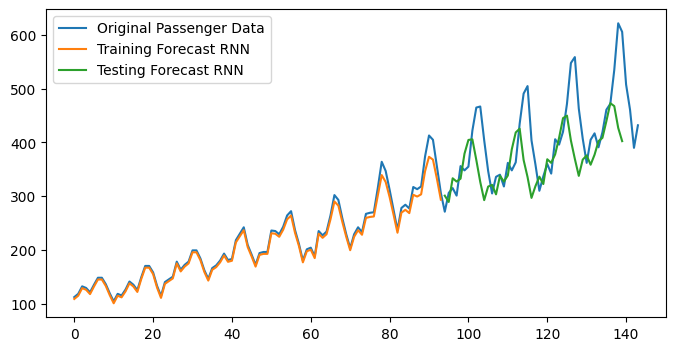

In [ ]:
keras.backend.clear_session()
# x_train and y_train are already ready, you can use them directly in the models

batch_size = 1
nb_neurons = 4

# input layer
input_layer = keras.layers.Input(batch_shape=[batch_size,x_train.shape[1],x_train.shape[2]])

# first hidden layer of an RNN containing nb_neurons
hidden_layer_1 = keras.layers.SimpleRNN(units=nb_neurons, return_sequences=True)(input_layer)
hidden_layer_2 = keras.layers.SimpleRNN(units=nb_neurons)(hidden_layer_1)

# last linear prediction layer that predicts a single real value
output_layer = keras.layers.Dense(units=1)(hidden_layer_2)

# create model
model_rnn = keras.models.Model(inputs=input_layer, outputs=output_layer)

model_rnn.summary()

# cost function for regression
cost_function = keras.losses.MeanSquaredError

# optimization algorithm
optimizer_algo = keras.optimizers.Adam(learning_rate=0.001)

# compile model
model_rnn.compile(loss=cost_function, optimizer=optimizer_algo)

# train
model_rnn.fit(x_train, y_train, epochs=100, batch_size=1, verbose=1)

# predict the train set
x_train_pred_rnn = model_rnn.predict(x_train)

# predict the train set
x_test_pred_rnn = model_rnn.predict(x_test)

# invert transformations
x_train_pred_rnn = scaler_toolbox.inverse_transform(x_train_pred_rnn)
#y_train_transformed = scaler_toolbox.inverse_transform([y_train])
x_test_pred_rnn = scaler_toolbox.inverse_transform(x_test_pred_rnn)
#y_test_transformed = scaler_toolbox.inverse_transform([y_test])

# performance
train_evaluation_rnn = np.sqrt(mean_squared_error(y_train_transformed[0], x_train_pred_rnn[:,0]))
print('Training Evaluation: %.2f RMSE' % (train_evaluation))
test_evaluation_rnn = np.sqrt(mean_squared_error(y_test_transformed[0], x_test_pred_rnn[:,0]))
print('Testing Evaluation: %.2f RMSE' % (test_evaluation))

# plot prediction
# Visualizing Original Data and Forecasts
plt.figure(figsize=(8,4))
plt.plot(scaler_toolbox.inverse_transform(normalized_passenger_data), label='Original Passenger Data')
plt.plot([item for item in x_train_pred_rnn], label='Training Forecast RNN')
plt.plot([item+len(x_train_pred_rnn) for item in range(len(x_test_pred_rnn))], x_test_pred_rnn, label='Testing Forecast RNN')
plt.legend()
plt.show()

# Classification problem

In this second example, we will see how LSTMs can be used to do sequence classification. We will be using the IMDB database which contains a set of movie reviews with their associated rating. The objective is therefore to classify the reviews as positive / negative by analyzing the text of the review.

## Word embedding
To facilitate text analysis, it is common to represent words by vectors of higher-dimensional numerical values. The similarity between words in terms of meaning is maintained by very close vectors in this vector space. This technique is called **word embedding**. This will be the first step to make in the network.

## Data preparation

### Download the dataset
The IMDB dataset has been pre-processed for ease of use. Each review is represented by a list of word clues. Words are indexed by and ordered by frequency of occurrence in the dataset. For example, index 3 represents the 3rd most frequent word in the dataset. The dataset contains only the most frequent 10,000 words.

In [ ]:
from keras.datasets import imdb

# We retrieve the data set by keeping only the 5000 most frequent words
top_words = 5000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=top_words)
print(x_train[0])
print(y_train[0])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 2, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 2, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 2, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 2, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 2, 19, 178, 32]
1


### Post a review for information
It is possible to retrieve the mapping between index and word to display a review. (Only the most frequent 5,000 words are used, which is why the review is not complete)

In [ ]:
word_to_id = keras.datasets.imdb.get_word_index()
id_to_word = {value:key for key,value in word_to_id.items()}
print(' '.join(id_to_word[id] for id in x_train[0] ))

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
the as you with out themselves powerful lets loves their becomes reaching had journalist of lot from anyone to have after out atmosphere never more room and it so heart shows to years of every never going and help moments or of every chest visual movie except her was several of enough more with is now current film as you of mine potentially unfortunately of you than him that with out themselves her get for was camp of you movie sometimes movie that with scary but and to story wonderful that in seeing in character to of 70s and with heart had shadows they of here that with her serious to have does when from why what have critics they is you that isn't one will very to as itself with other and in of seen over and for anyone of and br show's to whether from than out themselves history he name half some br of and odd was two most of mean for 1 any an boat she he should is thought and but of script you not while history he heart to real at an

### Resize reviews to the same lengths

In [ ]:
# resizing sequences
# We cut the sequence if too long
# Add leading zeros if too short
max_review_length = 500
x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=max_review_length)
x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=max_review_length)
print(x_train.shape)
print(y_train.shape)
print(x_train[0,:])

(25000, 500)
(25000,)
[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0

## LSTM classification

### Build model

In [ ]:
# input layer
inputs = keras.layers.Input(shape=(None,), dtype="int32")
# Embedding layer of each index in a 32-dimensional space
x = keras.layers.Embedding(top_words, 32)(inputs)
# LSTM layer
x = keras.layers.LSTM(100)(x)
# classification layer
outputs = keras.layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=["accuracy"])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, None, 32)       │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │        53,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 213,301 (833.21 KB)

 Trainable params: 213,301 (833.21 KB)

 Non-trainable params: 0 (0.00 B)

### model training

In [ ]:
batch_size=64
nb_epoch=5
model.fit(x_train, y_train, batch_size=batch_size, epochs=nb_epoch)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.7616 - loss: 0.4897
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.8581 - loss: 0.3401
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.8654 - loss: 0.3201
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9073 - loss: 0.2378
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9103 - loss: 0.2298


### Evaluate model on test

In [ ]:
# Evaluate model on test
scores = model.evaluate(x_test, y_test, verbose=0)
print("Accuracy: %.2f%%" % (scores[1]*100))

Accuracy: 87.53%


## **Exercices**

### Question
In the learning process, we see for each epoch an advancement ranging from 1 to 391. Explain what the value 391 corresponds to.

### Create a similar LSTM model but this time with two layers. Compare the results

In [ ]:
# Your code here !

### Correction:

In [ ]:
### model
# input layer
inputs = keras.layers.Input(shape=(None,), dtype="int32")
# Embedding layer of each index in a 32-dimensional space
x = keras.layers.Embedding(top_words, 32)(inputs)
# LSTM layer 1
x = keras.layers.LSTM(100, return_sequences=True)(x)
# LSTM layer 2
x = keras.layers.LSTM(100)(x)
# classification layer
outputs = keras.layers.Dense(1, activation="sigmoid")(x)
model2 = keras.Model(inputs, outputs)
model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=["accuracy"])
model2.summary()

### learning
batch_size=64
nb_epoch=5
model2.fit(x_train, y_train, batch_size=batch_size, epochs=nb_epoch)

# Evaluate model on test
scores = model2.evaluate(x_test, y_test, verbose=0)
print("Accuracy: %.2f%%" % (scores[1]*100))

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, None, 32)       │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, None, 100)      │        53,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 293,701 (1.12 MB)

 Trainable params: 293,701 (1.12 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.7729 - loss: 0.4710
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.8780 - loss: 0.3027
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - accuracy: 0.8929 - loss: 0.2683
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.8966 - loss: 0.2595
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.9229 - loss: 0.2043
Accuracy: 86.79%
